# 02 — Peptide Generation

This notebook walks through the peptide tiling process step by step for 2–3 example missense mutations from HCC1395.

For each mutation:
1. Look up the wildtype protein sequence
2. Apply the amino acid substitution
3. Tile overlapping k-mer windows spanning the mutation
4. Extract N- and C-terminal flanking sequences

All logic is in `neoantigen_pipeline.processing.peptide_generator`.

In [1]:
import sys
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Add src to path if running from notebooks directory
sys.path.insert(0, str(Path("../src").resolve()))

from neoantigen_pipeline.io.vcf_reader import VCFReader
from neoantigen_pipeline.io.proteome import ProteomeDB
from neoantigen_pipeline.candidates.peptide_generator import PeptideGenerator, PeptideCandidate
from neoantigen_pipeline.config import PeptideGenerationConfig

sns.set_style("whitegrid")
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (12, 5)

print("Imports OK")

Imports OK


In [2]:
# Define paths
DATA_DIR      = Path("../data/HCC1395_inputs")
VCF_PATH      = DATA_DIR / "annotated.expression.vcf.gz"
PROTEOME_PATH = DATA_DIR / "Homo_sapiens.GRCh38.pep.all.fa.gz"

print(f"VCF      : {VCF_PATH.exists()}")
print(f"Proteome : {PROTEOME_PATH.exists()}")

# Load components
print("\nLoading missense variants ...")
variants = VCFReader(str(VCF_PATH)).read_missense_variants()
print(f"  {len(variants)} missense variants loaded")

print("Loading proteome (may take a moment for gzipped FASTA) ...")
proteome = ProteomeDB(str(PROTEOME_PATH))
print("  Proteome loaded")

config    = PeptideGenerationConfig()
generator = PeptideGenerator(config, proteome)
print(f"\nPeptideGenerationConfig: {config}")

VCF      : True
Proteome : True

Loading missense variants ...
  1133 missense variants loaded
Loading proteome (may take a moment for gzipped FASTA) ...
  Proteome loaded

PeptideGenerationConfig: PeptideGenerationConfig(peptide_lengths=(8, 9, 10, 11), n_flank_length=10, c_flank_length=10)


## Selecting Example Mutations

In [3]:
# Pick the first 3 variants that have a valid transcript in the proteome
example_variants = []
for v in variants:
    if len(example_variants) >= 3:
        break
    if proteome.get_sequence(v.transcript_id) is not None:
        example_variants.append(v)

print(f"Selected {len(example_variants)} example variants with proteome entries:\n")
for i, v in enumerate(example_variants):
    seq = proteome.get_sequence(v.transcript_id)
    print(f"  [{i+1}] Gene={v.gene}  Transcript={v.transcript_id}")
    print(f"       Mutation={v.protein_change}  AA pos={v.aa_pos}  VAF={v.vaf}")
    print(f"       Protein length={len(seq) if seq else 'N/A'} aa")
    print()

Selected 3 example variants with proteome entries:

  [1] Gene=OR4F16  Transcript=ENST00000332831.5
       Mutation=p.Pro58Ala  AA pos=58  VAF=0.12782999873161316
       Protein length=312 aa

  [2] Gene=PRAMEF15  Transcript=ENST00000376152.2
       Mutation=p.Arg96His  AA pos=96  VAF=0.09825000166893005
       Protein length=478 aa

  [3] Gene=SRARP  Transcript=ENST00000329454.2
       Mutation=p.Gly100Trp  AA pos=100  VAF=1.0
       Protein length=169 aa



## Step-by-Step Peptide Generation

In [4]:
# --- Example variant 1 ---
if len(example_variants) >= 1:
    v = example_variants[0]
    print(f"Gene: {v.gene}  |  Mutation: {v.protein_change}")
    candidates_1 = generator.generate(v)
    print(f"  Peptide candidates generated: {len(candidates_1)}")

Gene: OR4F16  |  Mutation: p.Pro58Ala
  Peptide candidates generated: 38


In [5]:
# Show candidates for variant 1 as a DataFrame
if len(example_variants) >= 1 and candidates_1:
    rows = []
    for c in candidates_1:
        rows.append({
            "peptide_sequence"  : c.peptide_sequence,
            "wildtype_sequence" : c.wildtype_sequence,
            "peptide_length"    : c.peptide_length,
            "position_in_peptide": c.position_in_peptide,
            "n_flank"           : c.n_flank,
            "c_flank"           : c.c_flank,
        })
    df_1 = pd.DataFrame(rows)
    print(f"Variant 1 ({example_variants[0].gene} {example_variants[0].protein_change}) — first 10 candidates:")
    display(df_1.head(10))

Variant 1 (OR4F16 p.Pro58Ala) — first 10 candidates:


,peptide_sequence,wildtype_sequence,peptide_length,position_in_peptide,n_flank,c_flank
0,TDPHLHSA,TDPHLHSP,8,7,GNILIVFSVT,MYFLLASLSF
1,DPHLHSAM,DPHLHSPM,8,6,NILIVFSVTT,YFLLASLSFI
2,PHLHSAMY,PHLHSPMY,8,5,ILIVFSVTTD,FLLASLSFID
3,HLHSAMYF,HLHSPMYF,8,4,LIVFSVTTDP,LLASLSFIDL
4,LHSAMYFL,LHSPMYFL,8,3,IVFSVTTDPH,LASLSFIDLG
5,HSAMYFLL,HSPMYFLL,8,2,VFSVTTDPHL,ASLSFIDLGA
6,SAMYFLLA,SPMYFLLA,8,1,FSVTTDPHLH,SLSFIDLGAC
7,AMYFLLAS,PMYFLLAS,8,0,SVTTDPHLHS,LSFIDLGACS
8,TTDPHLHSA,TTDPHLHSP,9,8,TGNILIVFSV,MYFLLASLSF
9,TDPHLHSAM,TDPHLHSPM,9,7,GNILIVFSVT,YFLLASLSFI


In [6]:
# --- Example variant 2 ---
if len(example_variants) >= 2:
    v = example_variants[1]
    print(f"Gene: {v.gene}  |  Mutation: {v.protein_change}")
    candidates_2 = generator.generate(v)
    print(f"  Peptide candidates generated: {len                  (candidates_2)}")
    rows = []
    for c in candidates_2:
        rows.append({
            "peptide_sequence"   : c.peptide_sequence,
            "wildtype_sequence"  : c.wildtype_sequence,
            "peptide_length"     : c.peptide_length,
            "position_in_peptide": c.position_in_peptide,
            "n_flank"            : c.n_flank,
            "c_flank"            : c.c_flank,
        })
    df_2 = pd.DataFrame(rows)
    print(f"\nVariant 2 ({v.gene} {v.protein_change}) — first 10 candidates:")
    display(df_2.head(10))

Gene: PRAMEF15  |  Mutation: p.Arg96His
  Peptide candidates generated: 38

Variant 2 (PRAMEF15 p.Arg96His) — first 10 candidates:


,peptide_sequence,wildtype_sequence,peptide_length,position_in_peptide,n_flank,c_flank
0,ALLTQGVH,ALLTQGVR,8,7,AFQAVLDGLD,PRRWKLQVLD
1,LLTQGVHP,LLTQGVRP,8,6,FQAVLDGLDA,RRWKLQVLDL
2,LTQGVHPR,LTQGVRPR,8,5,QAVLDGLDAL,RWKLQVLDLQ
3,TQGVHPRR,TQGVRPRR,8,4,AVLDGLDALL,WKLQVLDLQD
4,QGVHPRRW,QGVRPRRW,8,3,VLDGLDALLT,KLQVLDLQDV
5,GVHPRRWK,GVRPRRWK,8,2,LDGLDALLTQ,LQVLDLQDVC
6,VHPRRWKL,VRPRRWKL,8,1,DGLDALLTQG,QVLDLQDVCE
7,HPRRWKLQ,RPRRWKLQ,8,0,GLDALLTQGV,VLDLQDVCEN
8,DALLTQGVH,DALLTQGVR,9,8,EAFQAVLDGL,PRRWKLQVLD
9,ALLTQGVHP,ALLTQGVRP,9,7,AFQAVLDGLD,RRWKLQVLDL


In [7]:
# --- Example variant 3 ---
if len(example_variants) >= 3:
    v = example_variants[2]
    print(f"Gene: {v.gene}  |  Mutation: {v.protein_change}")
    candidates_3 = generator.generate(v)
    print(f"  Peptide candidates generated: {len(candidates_3)}")
    rows = []
    for c in candidates_3:
        rows.append({
            "peptide_sequence"   : c.peptide_sequence,
            "wildtype_sequence"  : c.wildtype_sequence,
            "peptide_length"     : c.peptide_length,
            "position_in_peptide": c.position_in_peptide,
            "n_flank"            : c.n_flank,
            "c_flank"            : c.c_flank,
        })
    df_3 = pd.DataFrame(rows)
    print(f"\nVariant 3 ({v.gene} {v.protein_change}) — first 10 candidates:")
    display(df_3.head(10))

Gene: SRARP  |  Mutation: p.Gly100Trp
  Peptide candidates generated: 38

Variant 3 (SRARP p.Gly100Trp) — first 10 candidates:


,peptide_sequence,wildtype_sequence,peptide_length,position_in_peptide,n_flank,c_flank
0,TRVTPMGW,TRVTPMGG,8,7,VFCGENWPHL,GCLAQARATL
1,RVTPMGWG,RVTPMGGG,8,6,FCGENWPHLT,CLAQARATLP
2,VTPMGWGC,VTPMGGGC,8,5,CGENWPHLTR,LAQARATLPL
3,TPMGWGCL,TPMGGGCL,8,4,GENWPHLTRV,AQARATLPLC
4,PMGWGCLA,PMGGGCLA,8,3,ENWPHLTRVT,QARATLPLCR
5,MGWGCLAQ,MGGGCLAQ,8,2,NWPHLTRVTP,ARATLPLCRG
6,GWGCLAQA,GGGCLAQA,8,1,WPHLTRVTPM,RATLPLCRGS
7,WGCLAQAR,GGCLAQAR,8,0,PHLTRVTPMG,ATLPLCRGSV
8,LTRVTPMGW,LTRVTPMGG,9,8,IVFCGENWPH,GCLAQARATL
9,TRVTPMGWG,TRVTPMGGG,9,7,VFCGENWPHL,CLAQARATLP


## Visualising the Tiling Windows

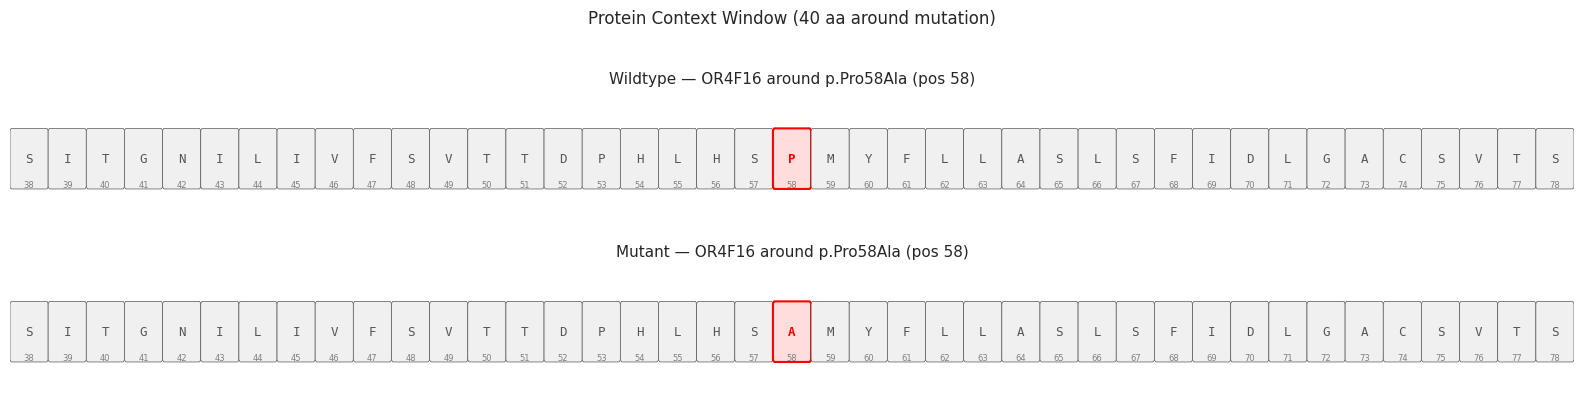

Wildtype : SITGNILIVFSVTTDPHLHSPMYFLLASLSFIDLGACSVTS
Mutant   : SITGNILIVFSVTTDPHLHSAMYFLLASLSFIDLGACSVTS


In [8]:
# Visualise protein context around the mutation for variant 1
# Show a 40-aa window with WT in gray, mutated position in red

if example_variants:
    v = example_variants[0]
    wt_seq = proteome.get_sequence(v.transcript_id)
    mut_pos = v.aa_pos - 1  # 0-indexed

    window_half = 20
    start = max(0, mut_pos - window_half)
    end   = min(len(wt_seq), mut_pos + window_half + 1)

    wt_window  = wt_seq[start:end]
    mut_window = list(wt_window)
    local_mut  = mut_pos - start
    if 0 <= local_mut < len(mut_window):
        mut_window[local_mut] = v.aa_alt
    mut_window = "".join(mut_window)

    fig, axes = plt.subplots(2, 1, figsize=(16, 4))

    for ax, seq, label in [(axes[0], wt_window, "Wildtype"), (axes[1], mut_window, "Mutant")]:
        ax.set_xlim(-0.5, len(seq) - 0.5)
        ax.set_ylim(-0.5, 1.5)
        ax.axis("off")
        ax.set_title(f"{label} — {v.gene} around {v.protein_change} (pos {v.aa_pos})", fontsize=11)
        for i, aa in enumerate(seq):
            pos_in_protein = start + i
            is_mut = (pos_in_protein == mut_pos)
            color     = "red"   if is_mut else "#555555"
            bg_color  = "#FFDDDD" if is_mut else "#F0F0F0"
            rect = mpatches.FancyBboxPatch(
                (i - 0.45, 0.1), 0.9, 0.8,
                boxstyle="round,pad=0.05",
                facecolor=bg_color, edgecolor=color, linewidth=1.5 if is_mut else 0.5
            )
            ax.add_patch(rect)
            ax.text(i, 0.5, aa, ha="center", va="center", fontsize=9,
                    color=color, fontweight="bold" if is_mut else "normal",
                    fontfamily="monospace")
            ax.text(i, 0.05, str(pos_in_protein + 1), ha="center", va="bottom",
                    fontsize=6, color="gray")

    plt.suptitle("Protein Context Window (40 aa around mutation)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Wildtype : {wt_window}")
    print(f"Mutant   : {mut_window}")

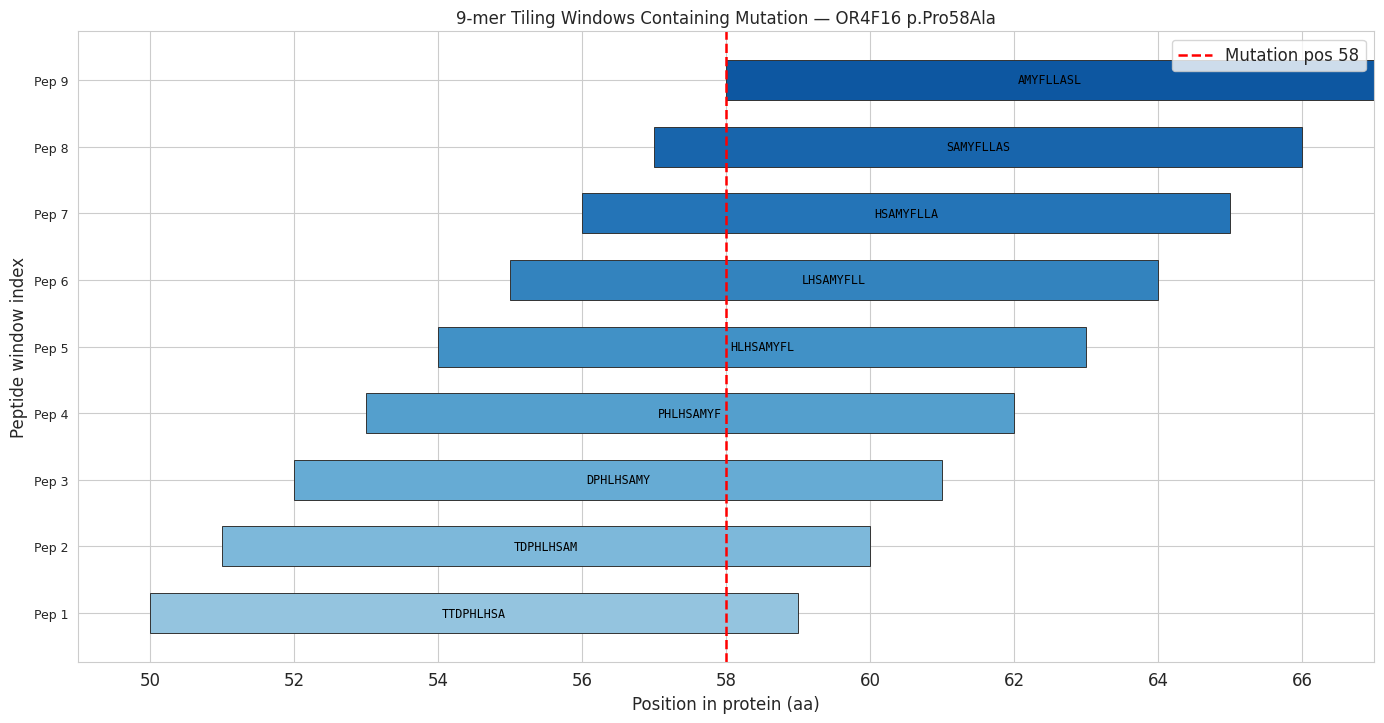

9-mer peptides containing the mutation: 9


In [9]:
# Tiling diagram: show all 9-mer windows containing the mutation as horizontal bars

if example_variants:
    v        = example_variants[0]
    cands_9  = [c for c in generator.generate(v) if c.peptide_length == 9]
    mut_pos  = v.aa_pos  # 1-indexed protein position

    # Compute start/end positions in protein coordinates
    pep_positions = []
    for c in cands_9:
        # position_in_peptide: 0-indexed position of mutation within the peptide
        pep_start = mut_pos - c.position_in_peptide  # 1-indexed start in protein
        pep_end   = pep_start + c.peptide_length - 1
        pep_positions.append((pep_start, pep_end, c.peptide_sequence))

    fig, ax = plt.subplots(figsize=(14, max(4, len(pep_positions) * 0.6 + 2)))

    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(pep_positions)))
    for i, (start, end, seq) in enumerate(pep_positions):
        ax.barh(i, end - start + 1, left=start, height=0.6,
                color=colors[i], edgecolor="#333", linewidth=0.7)
        ax.text(start + (end - start + 1) / 2, i, seq,
                ha="center", va="center", fontsize=8.5, fontfamily="monospace",
                color="black")

    ax.axvline(mut_pos, color="red", linestyle="--", linewidth=1.8, label=f"Mutation pos {mut_pos}")
    ax.set_xlabel("Position in protein (aa)")
    ax.set_ylabel("Peptide window index")
    ax.set_title(f"9-mer Tiling Windows Containing Mutation — {v.gene} {v.protein_change}", fontsize=12)
    ax.legend(loc="upper right")
    ax.set_yticks(range(len(pep_positions)))
    ax.set_yticklabels([f"Pep {i+1}" for i in range(len(pep_positions))], fontsize=9)
    if pep_positions:
        all_starts = [p[0] for p in pep_positions]
        all_ends   = [p[1] for p in pep_positions]
        ax.set_xlim(min(all_starts) - 1, max(all_ends) + 1)
    plt.tight_layout()
    plt.show()
    print(f"9-mer peptides containing the mutation: {len(pep_positions)}")

## Flanking Sequences

Flanking sequences (N-flank upstream, C-flank downstream) are used by MHCflurry's antigen processing model to predict proteasomal cleavage.

In [10]:
# Display flanking sequences for first variant, 9-mers only
if example_variants and cands_9:
    rows = []
    for c in cands_9[:10]:
        rows.append({
            "n_flank"         : c.n_flank if c.n_flank else "(start)",
            "peptide_sequence": c.peptide_sequence,
            "c_flank"         : c.c_flank if c.c_flank else "(end)",
            "mut_pos_in_pep"  : c.position_in_peptide,
        })
    df_flanks = pd.DataFrame(rows)

    print(f"Flanking sequences for {example_variants[0].gene} {example_variants[0].protein_change} (9-mers, first 10):")
    print("\nFormat: [N-flank] | [peptide] | [C-flank]\n")
    for _, row in df_flanks.iterrows():
        print(f"  {row['n_flank']:>10s} | {row['peptide_sequence']} | {row['c_flank']:<10s}   (mut at pos {row['mut_pos_in_pep']+1})")
    print()
    display(df_flanks)

Flanking sequences for OR4F16 p.Pro58Ala (9-mers, first 10):

Format: [N-flank] | [peptide] | [C-flank]

  TGNILIVFSV | TTDPHLHSA | MYFLLASLSF   (mut at pos 9)
  GNILIVFSVT | TDPHLHSAM | YFLLASLSFI   (mut at pos 8)
  NILIVFSVTT | DPHLHSAMY | FLLASLSFID   (mut at pos 7)
  ILIVFSVTTD | PHLHSAMYF | LLASLSFIDL   (mut at pos 6)
  LIVFSVTTDP | HLHSAMYFL | LASLSFIDLG   (mut at pos 5)
  IVFSVTTDPH | LHSAMYFLL | ASLSFIDLGA   (mut at pos 4)
  VFSVTTDPHL | HSAMYFLLA | SLSFIDLGAC   (mut at pos 3)
  FSVTTDPHLH | SAMYFLLAS | LSFIDLGACS   (mut at pos 2)
  SVTTDPHLHS | AMYFLLASL | SFIDLGACSV   (mut at pos 1)



,n_flank,peptide_sequence,c_flank,mut_pos_in_pep
0,TGNILIVFSV,TTDPHLHSA,MYFLLASLSF,8
1,GNILIVFSVT,TDPHLHSAM,YFLLASLSFI,7
2,NILIVFSVTT,DPHLHSAMY,FLLASLSFID,6
3,ILIVFSVTTD,PHLHSAMYF,LLASLSFIDL,5
4,LIVFSVTTDP,HLHSAMYFL,LASLSFIDLG,4
5,IVFSVTTDPH,LHSAMYFLL,ASLSFIDLGA,3
6,VFSVTTDPHL,HSAMYFLLA,SLSFIDLGAC,2
7,FSVTTDPHLH,SAMYFLLAS,LSFIDLGACS,1
8,SVTTDPHLHS,AMYFLLASL,SFIDLGACSV,0
